In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
from itertools import combinations
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
class qPCRdf: # define a class that includes qPCR dataframe obtained from qPCR machine
    """
    class qPCRdf: qPCR dataframe exported from qPCR machine
    Finding summary statistics for the ct_values
    Plotting graphes such as delta_ct difference and computing statistical analysis
    """
    
    def __init__(self,file_name):
        self.file_name = file_name
        self.df = pd.read_excel(self.file_name)
        self.df = self.df.drop(['Unnamed: 0', 'Fluor', 'SQ','Well'], axis=1, errors='ignore')
        #if self.df.loc[self.df['Target'] == 'Control', 'Cq'].notna().any():
            #raise ValueError('Ct value for controls should be NaN,but some are not')
        self.df['TechRep']=self.df.groupby(['Target','Content', 'Sample']).cumcount()
        self.df = self.df[~self.df['Content'].isin(['Uninjected', 'No RNA', 'No enzyme', 'No water'])]
        self.df=self.df.dropna(subset=['Cq']).reset_index(drop=True) # drop samples with any missing values
        
    def remove_outliers(self):
        def clean_dataframe(group):
            grouped=group['Cq'].to_numpy()
            median=np.median(grouped) #find out the median of technical variable
            range_=np.ptp(grouped) #find out the range of technical variables
            if range_>1:
                distance=np.abs(grouped-median)
                outlier_index=np.argmax(distance)
                clean_group= group.drop(group.index[outlier_index])
            else:
                clean_group=group.copy()
                
            target, content, sample = group.name
            clean_group['Target'] = target
            clean_group['Content'] = content
            clean_group['Sample'] = sample
           
            return clean_group
                
        self.df = self.df.groupby(['Target', 'Content', 'Sample'], group_keys=False).apply(clean_dataframe).reset_index(drop=True)
        self.df = self.df[['Target', 'Content', 'Sample', 'Cq','TechRep']]
        return self

    
        
    def Target(self):
        df=self.df
        return df[df['Target']!='SDHA'].reset_index().drop(columns=['index'])
        
    def Housekeeping(self):
        df=self.df
        return df[df['Target']=='SDHA'].reset_index().drop(columns=['index'])
    
    def Delta_Ct(self):
        Ct_Housekeeping=self.Housekeeping()
        Ct_Target=self.Target()
        Ct_Housekeeping_mean = Ct_Housekeeping.groupby(["Content", "Sample"], as_index=False)["Cq"].mean().rename(columns={"Cq": "mean_cq_housekeeping"})
        Ct_Target_mean =Ct_Target.groupby(["Content", "Sample"], as_index=False)["Cq"].mean().rename(columns={"Cq": "mean_cq_target"})
        merged = Ct_Target_mean.merge(Ct_Housekeeping_mean,on=["Content", "Sample"],how="inner")
    
        merged["avg_delta_ct"]=merged['mean_cq_target']-merged['mean_cq_housekeeping']
        
        return merged 
        
    def Delta_Delta_Ct_from_plates(self, qpcr_objects, base_line):
        all_dfs = [self.Delta_Ct().copy()]
        for qpcr in qpcr_objects:
            all_dfs.append(qpcr.Delta_Ct().copy())
        combined = pd.concat(all_dfs, ignore_index=True)
        baseline_mean_delta_ct = combined.loc[combined["Content"] == base_line,"avg_delta_ct"].mean()
        combined["delta_delta_ct"] = combined["avg_delta_ct"] - baseline_mean_delta_ct
        combined["fold_change"] = 2 ** (-combined["delta_delta_ct"])
        return combined
    
    def normality_check(self,qpcr_objects,base_line,para):
        df = self.Delta_Delta_Ct_from_plates(qpcr_objects,base_line)

        model = ols(f"{para} ~ C(Content)", data=df).fit()

        residuals = model.resid
        anova_table = sm.stats.anova_lm(model, typ=1)

        # levene test for constant variance check
        groups=[group["delta_delta_ct"] for name,group in df.groupby('Content')]
        stat, p = stats.levene(*groups)
        print(f'The p value for levene test is {p}'), print(anova_table)
        sm.qqplot(residuals, line="45")
        plt.title("Q-Q plot of residuals")
        plt.show()

    def repoted_data(self,qpcr_objects,base_line):
        df = self.Delta_Delta_Ct_from_plates(qpcr_objects,base_line)
        summary = (
        df.groupby("Content").agg(mean_delta_delta_ct=("delta_delta_ct", "mean"),sd_delta_delta_ct=("delta_delta_ct", "std"),n=("Sample", "count"))
        .reset_index())

        summary["reported_fold_change"] = 2 ** (-summary["mean_delta_delta_ct"])
        summary["log2_fold_change"] = -summary["mean_delta_delta_ct"]
        return summary

    
    def qc_boxplot(self,qpcr_objects,base_line):
        fig, axes = plt.subplots(1, 2, figsize=(13, 8))
        ddct_df = self.Delta_Delta_Ct_from_plates(qpcr_objects,base_line)
        
        sns.boxplot(x= 'Content',y= 'delta_delta_ct',data=ddct_df,ax=axes[0],showmeans=True)
        axes[0].set_title('Delta_Delta_Ct comparasion')
        
        sns.barplot(x="Content",y="log2_fold_change",data=self.repoted_data(qpcr_objects,base_line),errorbar=None, ax=axes[1])
        axes[1].axhline(0, linestyle="--")
        axes[1].set_title('Fold_Change comparasion')
        
        plt.tight_layout()
        plt.show()
    
    def plot_difference(self,qpcr_objects, base_line ,unique_group, value,statistic_test):
        '''
        Run and produce a pair-wise comparasion plot between subgroups using the given statistical tests 
        '''
        ct_mean=self.Delta_Delta_Ct_from_plates(qpcr_objects,base_line)
        ax = sns.boxplot(x=unique_group, y= value, data=ct_mean)
        sns.stripplot(x=unique_group, y= value, data=ct_mean, color='black', alpha=0.6)
        pairs = list(combinations(ct_mean[unique_group].unique(), 2))
        annotator = Annotator(ax, pairs, data=ct_mean, x=unique_group, y= value)
        annotator.configure(test=statistic_test,        # or 't-test_ind', 'Mann-Whitney'
                            text_format='star',    # shows *, **, ***
                            loc='inside')           # or 'outside'
        annotator.apply_and_annotate()
        plt.show()

In [3]:
promoter_control=qPCRdf('promoter control -  Quantification Summary.xlsx').remove_outliers()
promoter_tested=qPCRdf('qPCR test_promoter.xlsx').remove_outliers()

In [4]:
promoter_tested.Delta_Ct()

,Content,Sample,mean_cq_target,mean_cq_housekeeping,avg_delta_ct
0,BP1500,1.0,28.003763,24.373859,3.629905
1,BP1500,2.0,29.322764,24.598699,4.724065
2,BP1500,3.0,27.846550,24.984268,2.862282
3,BP1500,4.0,31.738940,25.890000,5.848939
4,BP1500,5.0,30.447048,25.534878,4.912170
5,BP400,1.0,33.368336,28.851467,4.516869
6,BP400,2.0,31.350010,25.357706,5.992305
7,BP400,3.0,32.676754,26.878114,5.798640
8,BP400,4.0,33.966693,29.091216,4.875476
9,BP700,1.0,31.155986,26.796954,4.359032


In [13]:
promoter_control.Delta_Delta_Ct_from_plates([promoter_tested], 'ProA1')

,Content,Sample,mean_cq_target,mean_cq_housekeeping,avg_delta_ct,delta_delta_ct,fold_change
0,PR1.7,1.0,28.532627,25.714766,2.817861,-2.483201,5.591368
1,PR1.7,2.0,31.588761,27.050668,4.538094,-0.762968,1.696979
2,PR1.7,3.0,34.409782,25.192898,9.216884,3.915822,0.066255
3,PR1.7,4.0,31.794643,25.255740,6.538903,1.237841,0.424007
4,PR1.7,5.0,26.645181,25.280662,1.364519,-3.936543,15.311492
5,ProA1,1.0,31.561871,25.929155,5.632716,0.331654,0.794625
6,ProA1,2.0,30.263028,26.615165,3.647863,-1.653199,3.145304
7,ProA1,3.0,30.924082,25.072119,5.851962,0.550900,0.682594
8,ProA1,4.0,30.103777,25.161070,4.942707,-0.358355,1.281964
9,ProA1,5.0,30.725070,24.295006,6.430063,1.129001,0.457232


The p value for levene test is 0.12734565849230978
              df     sum_sq   mean_sq         F    PR(>F)
C(Content)   4.0   2.829075  0.707269  0.222106  0.922557
Residual    18.0  57.318683  3.184371       NaN       NaN


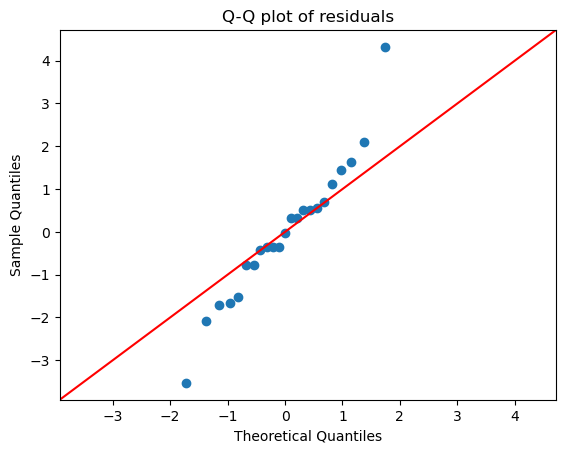

In [6]:
promoter_control.normality_check([promoter_tested],'ProA1','delta_delta_ct')

In [7]:
promoter_control.repoted_data([promoter_tested],'PR1.7')

,Content,mean_delta_delta_ct,sd_delta_delta_ct,n,reported_fold_change,log2_fold_change
0,BP1500,-0.499780,1.164504,5,1.413998,0.499780
1,BP400,0.400570,0.712126,4,0.757559,-0.400570
2,BP700,-0.175367,1.584943,4,1.129252,0.175367
3,PR1.7,0.000000,3.093836,5,1.000000,-0.000000
4,ProA1,0.405810,1.066491,5,0.754812,-0.405810


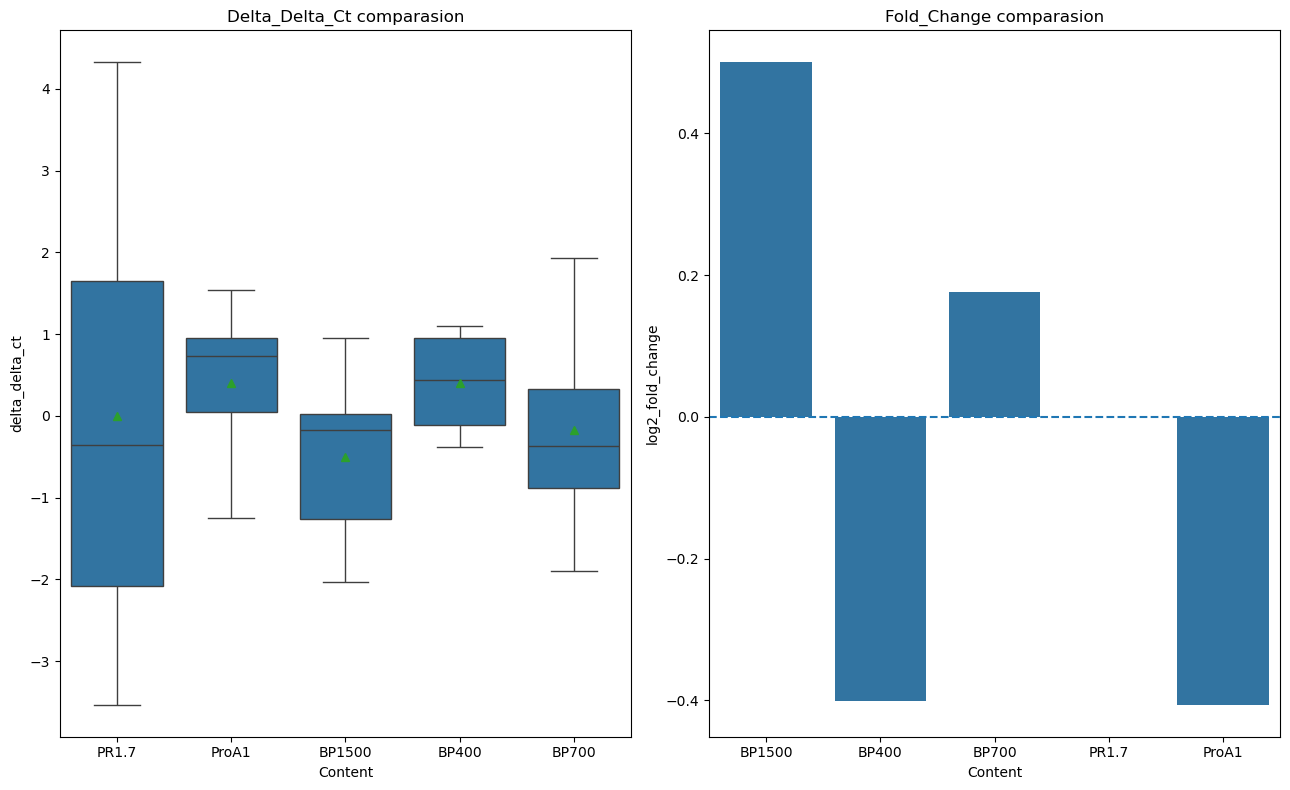

In [8]:
promoter_control.qc_boxplot([promoter_tested],'PR1.7')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

PR1.7 vs. ProA1: t-test independent samples, P_val:7.886e-01 t=-2.773e-01
ProA1 vs. BP1500: t-test independent samples, P_val:2.356e-01 t=1.282e+00
BP1500 vs. BP400: t-test independent samples, P_val:2.198e-01 t=-1.347e+00
BP400 vs. BP700: t-test independent samples, P_val:5.320e-01 t=6.629e-01
PR1.7 vs. BP1500: t-test independent samples, P_val:7.440e-01 t=3.381e-01
ProA1 vs. BP400: t-test independent samples, P_val:9.935e-01 t=8.387e-03
BP1500 vs. BP700: t-test independent samples, P_val:7.328e-01 t=-3.554e-01
PR1.7 vs. BP400: t-test independent samples, P_val:8.095e-01 t=-2.504e-01
ProA1 vs. BP700: t-test independent samples, P_val:5.308e-01 t=6.593e-01
PR1.7 vs. BP700: t-test independent samples, P_val:9.215e-01 t=1.022e-01


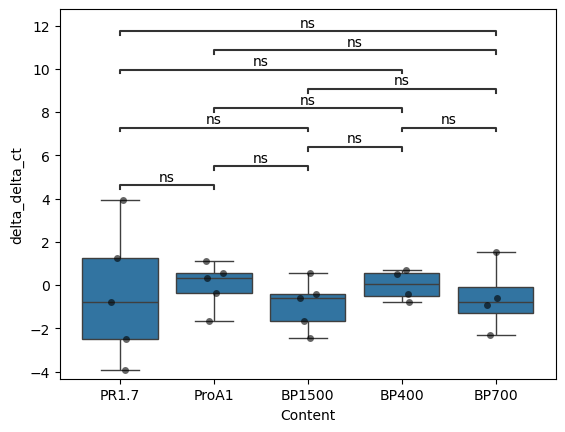

In [9]:
promoter_control.plot_difference([promoter_tested],'ProA1','Content','delta_delta_ct', 't-test_ind')